In [3]:
import sys
sys.path.append('../../../../../src')
sys.path.append('../../../../..')

import os
from PIL import ImageFont
import matplotlib.pyplot as plt
import numpy as np
from palette.symbol2value import get_asciis
from image.processing import DITHER_MODES
from converters.tile.bin_1d import Tile2Symb1dBin

from tests.experimental.converters.test_loop import Params, test_loop

SYMBOLS = get_asciis()
FONT_PATH = "../../../../../fonts/CascadiaMono.ttf"
FONT_SIZE = 11
IMG_SET_PATH = "../../../../../imgs/BSDS500"
IMG_PATHS = [os.path.join(IMG_SET_PATH, img_name)
             for img_name in os.listdir(IMG_SET_PATH)[:5]]

def make_converter(params: Params):
    return Tile2Symb1dBin(
        symbols=SYMBOLS,
        font=ImageFont.truetype(params.font_path, params.font_size),
        **params.converter_args)

Min: 0.0844 | Max: 0.3311 | Mean: 0.1841 | Std: 0.0926
Min: 0.1222 | Max: 0.2840 | Mean: 0.1952 | Std: 0.0711
Min: 0.1007 | Max: 0.3663 | Mean: 0.2001 | Std: 0.0911
Min: 0.0838 | Max: 0.3145 | Mean: 0.1946 | Std: 0.0908
Min: 0.1040 | Max: 0.2054 | Mean: 0.1325 | Std: 0.0377
Min: 0.1053 | Max: 0.2120 | Mean: 0.1426 | Std: 0.0384
Min: 0.0419 | Max: 0.1556 | Mean: 0.1020 | Std: 0.0419
Min: 0.0813 | Max: 0.1153 | Mean: 0.0983 | Std: 0.0130
Min: 0.0404 | Max: 0.0985 | Mean: 0.0733 | Std: 0.0190
Min: 0.0967 | Max: 0.1095 | Mean: 0.1029 | Std: 0.0050


C:\Users\wojte\AppData\Local\Temp\ipykernel_8664\589972136.py:27: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(similarity_scores,


Min: 0.0770 | Max: 0.1271 | Mean: 0.1064 | Std: 0.0166


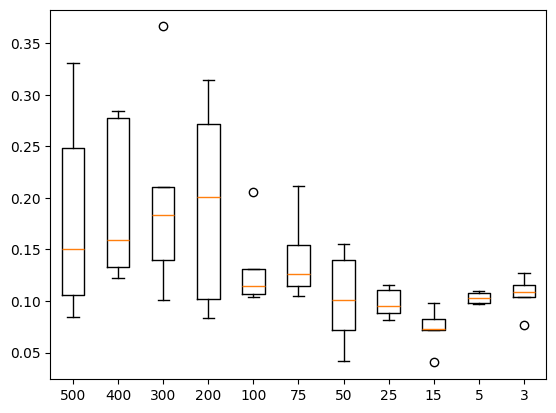

In [4]:
# window width

params_space = [
    w for w in range(500, 100, -100)
]
params_space += [
    w for w in range(100, 25, -25)
]
params_space += [
    w for w in range(25, 5, -10)
]
params_space += [
    w for w in range(5, 2, -2)
]

params_space = list(
    map(lambda w: Params(
        win_width=w,
        font_path=FONT_PATH,
        font_size=FONT_SIZE,
        converter_args={},
        preprocess_args={}),
        params_space))

similarity_scores = test_loop(IMG_PATHS, make_converter, params_space)

plt.boxplot(similarity_scores,
            labels=[param.win_width for param in params_space])
plt.show()

Min: 0.0287 | Max: 0.0536 | Mean: 0.0397 | Std: 0.0081
Min: 0.0733 | Max: 0.1014 | Mean: 0.0925 | Std: 0.0101
Min: 0.0902 | Max: 0.1150 | Mean: 0.1010 | Std: 0.0104
Min: 0.1039 | Max: 0.1200 | Mean: 0.1096 | Std: 0.0065
Min: 0.1000 | Max: 0.1276 | Mean: 0.1090 | Std: 0.0101
Min: 0.1039 | Max: 0.1259 | Mean: 0.1152 | Std: 0.0081
Min: 0.1007 | Max: 0.1173 | Mean: 0.1071 | Std: 0.0069
Min: 0.1002 | Max: 0.1275 | Mean: 0.1110 | Std: 0.0106
Min: 0.0973 | Max: 0.1175 | Mean: 0.1067 | Std: 0.0084


C:\Users\wojte\AppData\Local\Temp\ipykernel_8664\969975796.py:21: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(similarity_scores,


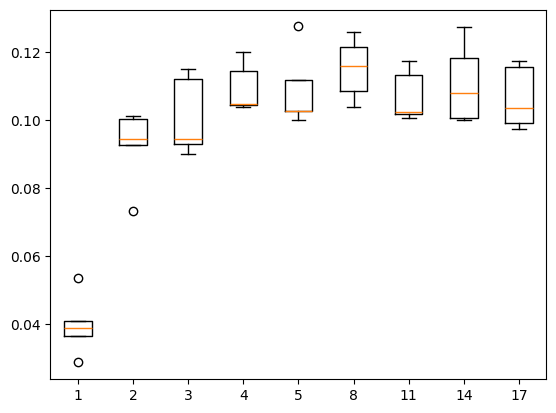

In [5]:
# bins

params_space = [
    bins for bins in range(1, 5, 1)
]
params_space += [
    bins for bins in range(5, 18, 3)
]

params_space = list(
    map(lambda bins: Params(
        win_width=5,
        font_path=FONT_PATH,
        font_size=FONT_SIZE,
        converter_args={'bins': bins},
        preprocess_args={}),
        params_space))

similarity_scores = test_loop(IMG_PATHS, make_converter, params_space)

plt.boxplot(similarity_scores,
            labels=[param.converter_args['bins'] for param in params_space])
plt.show()

In [6]:
# dithering

params_space = [
    {'quantize_colors': 256, 'dither': DITHER_MODES.NONE},
    {'quantize_colors': 2, 'dither': DITHER_MODES.FS},
    {'quantize_colors': 2, 'dither': DITHER_MODES.BAYER}
]

params_space = list(
    map(lambda preprocess_args: Params(
        win_width=5,
        font_path=FONT_PATH,
        font_size=FONT_SIZE,
        converter_args={},
        preprocess_args=preprocess_args),
        params_space))

similarity_scores = test_loop(IMGS, make_converter, params_space)

plt.boxplot(similarity_scores,
            labels=[param.preprocess_args['dither'] for param in params_space])
plt.show()

NameError: name 'IMGS' is not defined

C:\Users\wojte\AppData\Local\Temp\ipykernel_19152\3619433642.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(similarity_scores,


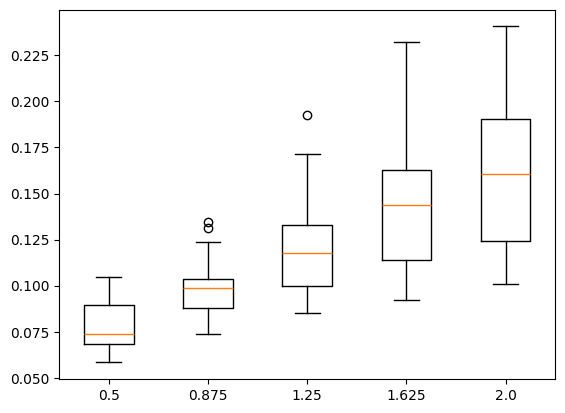

In [ ]:
# contrast

params_space = [
    {'contrast': c} for c in np.linspace(0.5, 2.0, 5, endpoint=True)
]

params_space = list(
    map(lambda preprocess_args: Params(
        win_width=5,
        font_path=FONT_PATH,
        font_size=FONT_SIZE,
        converter_args={},
        preprocess_args=preprocess_args),
        params_space))

similarity_scores = test_loop(IMGS, make_converter, params_space)

plt.boxplot(similarity_scores,
            labels=[param.preprocess_args['contrast'] for param in params_space])
plt.show()